In [1]:
# libraries for data processing and basic plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define complete list of column headers for auto.csv
headers = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration", 
    "num-of-doors", "body-style", "drive-wheels", "engine-location", 
    "wheel-base", "length", "width", "height", "curb-weight", 
    "engine-type", "num-of-cylinders", "engine-size", "fuel-system", 
    "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm", 
    "city-mpg", "highway-mpg", "price"
]

# Load dataset from CSV file and assign headers
df = pd.read_csv(r'C:\Users\MANSO\Desktop\Assignments_Data_Science\Data_Analysis\auto.csv', names=headers)
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


In [2]:
# Converting 'price' and 'horsepower' to numeric to calculate accurate stats
# errors='coerce' so that any remaining '?' turns into NaN (null value)
df['price'] = pd.to_numeric(df.replace('?', np.nan)['price'], errors='coerce')
df['horsepower'] = pd.to_numeric(df.replace('?', np.nan)['horsepower'], errors='coerce')

# Generate descriptive statistics for all numeric columns (includes mean, median, std dev)
print("--- Descriptive Statistics for Key Features ---")
df[['price', 'horsepower', 'engine-size', 'city-mpg']].describe()

--- Descriptive Statistics for Key Features ---


,price,horsepower,engine-size,city-mpg
count,201.000000,203.000000,205.000000,205.000000
mean,13207.129353,104.256158,126.907317,25.219512
std,7947.066342,39.714369,41.642693,6.542142
min,5118.000000,48.000000,61.000000,13.000000
25%,7775.000000,70.000000,97.000000,19.000000
50%,10295.000000,95.000000,120.000000,24.000000
75%,16500.000000,116.000000,141.000000,30.000000
max,45400.000000,288.000000,326.000000,49.000000


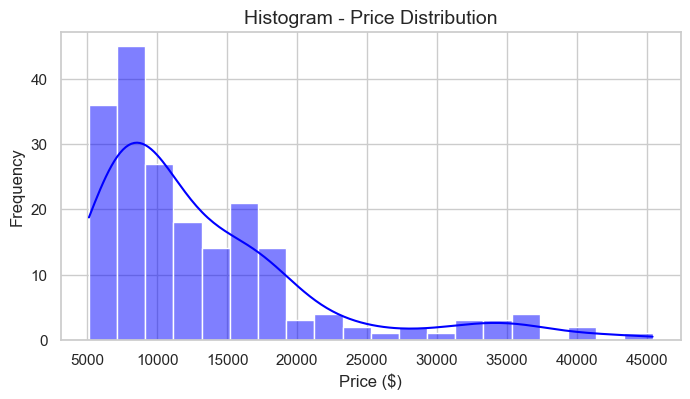

In [3]:
# Set the plot style and size configurations
sns.set_theme(style="whitegrid")

# 1. Histogram for Price
plt.figure(figsize=(8, 4))
sns.histplot(df['price'].dropna(), bins=20, kde=True, color='blue')
plt.title('Histogram - Price Distribution', fontsize=14)
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.savefig('histogram_price.png', bbox_inches='tight')
plt.show()



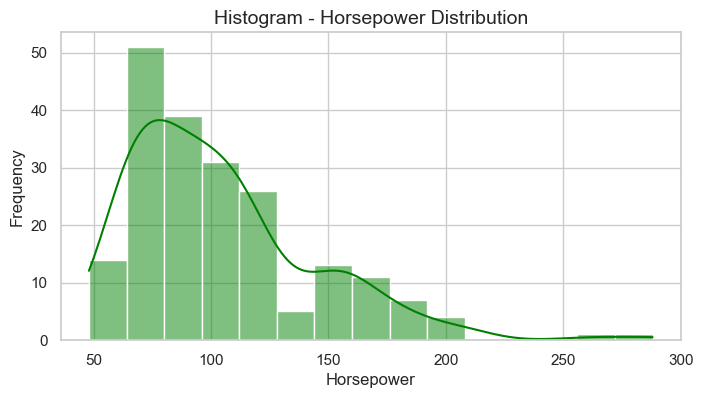

In [4]:
# 2. Histogram for Horsepower
plt.figure(figsize=(8, 4))
sns.histplot(df['horsepower'].dropna(), bins=15, kde=True, color='green')
plt.title('Histogram - Horsepower Distribution', fontsize=14)
plt.xlabel('Horsepower')
plt.ylabel('Frequency')
plt.savefig('histogram_horsepower.png', bbox_inches='tight')
plt.show()



C:\Users\MANSO\AppData\Local\Temp\ipykernel_16964\2944726001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='body-style', y='price', data=df, palette='Set2')


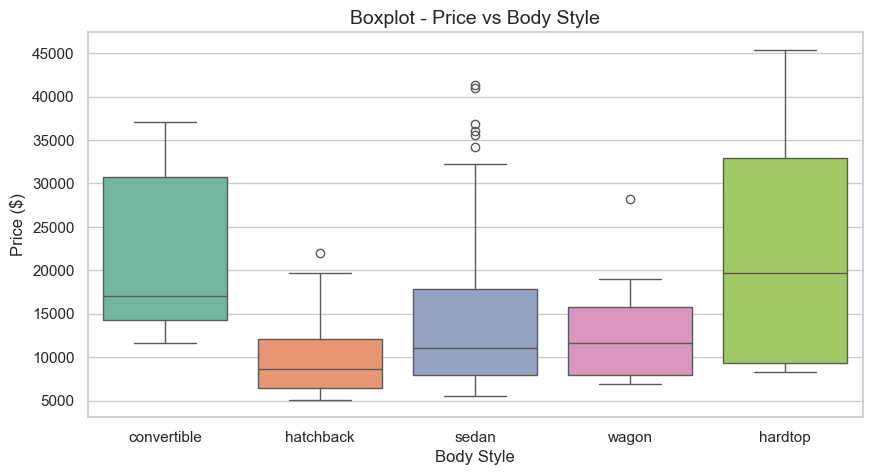

In [5]:
# 3. Boxplot - Price vs Body Style
plt.figure(figsize=(10, 5))
sns.boxplot(x='body-style', y='price', data=df, palette='Set2')
plt.title('Boxplot - Price vs Body Style', fontsize=14)
plt.xlabel('Body Style')
plt.ylabel('Price ($)')
plt.savefig('boxplot_price_body_style.png', bbox_inches='tight')
plt.show()

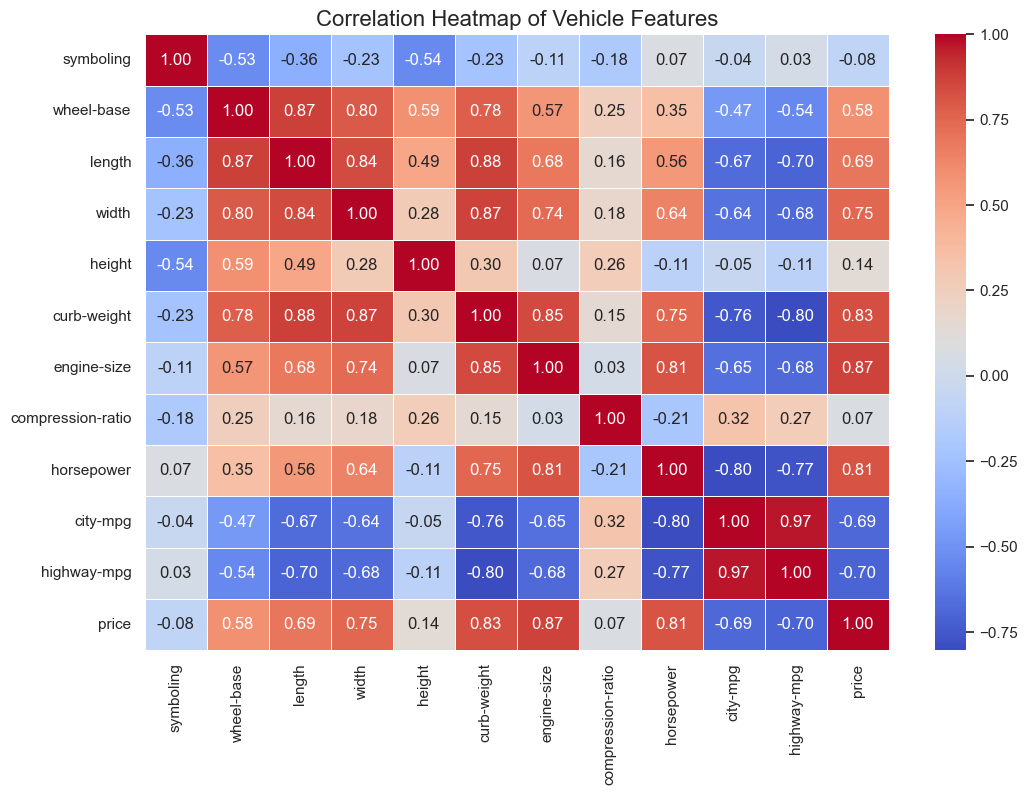

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# correlation matrix:clean heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Vehicle Features', fontsize=16)
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [7]:
# TASK 2: Data Preprocessing & Feature Engineering 
# Replace all "?" placeholders with standard NaN (Not a Number) missing values
df.replace('?', np.nan, inplace=True)

# Count how many missing values exist in each column
missing_data = df.isnull().sum()

# Filter out and display only columns that contain at least one missing value
print("--- Columns with Missing Values ---")
print(missing_data[missing_data > 0])

--- Columns with Missing Values ---
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64


In [8]:
#  Missing values handling and types convertion

# Replace missing values in numerical columns by converting to numeric first
num_cols_to_impute = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']

for col in num_cols_to_impute:
# column to numeric type first. Any '?' automatically becomes NaN.
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
# Mean of the numeric column (ignoring NaNs)
    col_mean = df[col].mean()
    
# Missing values with calculated mean
    df[col] = df[col].fillna(col_mean)

most_frequent_doors = df['num-of-doors'].mode()[0]
df['num-of-doors'] = df['num-of-doors'].fillna(most_frequent_doors)

# For target variable 'price', convert to numeric and drop rows without a price
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df.dropna(subset=['price'], axis=0, inplace=True)

# Reset index since we dropped rows
df.reset_index(drop=True, inplace=True)

print("Total missing values left in dataset:", df.isnull().sum().sum())

Total missing values left in dataset: 0


In [9]:
# Convert normalized-losses to an integer type as it contains no NaNs
df['normalized-losses'] = df['normalized-losses'].astype('int')

print("Final Data Type Check:")
print(df[['price', 'horsepower', 'normalized-losses', 'bore', 'stroke']].dtypes)

# Create new column: df["city-L/100km"] = 235 / df["city-mpg"] 
df["city-L/100km"] = 235 / df["city-mpg"]

# Verify the new column creation alongside the original
df[['city-mpg', 'city-L/100km']].head()

Final Data Type Check:
price                float64
horsepower           float64
normalized-losses      int64
bore                 float64
stroke               float64
dtype: object


,city-mpg,city-L/100km
0,21,11.190476
1,21,11.190476
2,19,12.368421
3,24,9.791667
4,18,13.055556


In [10]:
# Apply Binning to Horsepower: Define 4 boundaries to create 3 segments (Low, Medium, High)
bins = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)
group_names = ['Low', 'Medium', 'High']

df['horsepower-binned'] = pd.cut(df['horsepower'], bins, labels=group_names, include_lowest=True)

# Normalize 'length' feature using Simple Feature Scaling
df['length'] = df['length'] / df['length'].max()

print("Binning and normalization successfully completed!")
print("\nHorsepower value counts per bin:")
print(df['horsepower-binned'].value_counts())

Binning and normalization successfully completed!

Horsepower value counts per bin:
horsepower-binned
Low       153
Medium     43
High        5
Name: count, dtype: int64


In [11]:
#Model Development (Regression): Part A: Linear Regression 
from sklearn.model_selection import train_test_split

# Select predictive features and target variable
features = ['horsepower', 'engine-size', 'curb-weight', 'highway-mpg']
X = df[features]
y = df['price']

# Experiment 1: 80% Train / 20% Test Split
X_train80, X_test20, y_train80, y_test20 = train_test_split(X, y, test_size=0.20, random_state=42)

# Experiment 2: 70% Train / 30% Test Split
X_train70, X_test30, y_train70, y_test30 = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"80/20 split sets shapes: Train={X_train80.shape}, Test={X_test20.shape}")
print(f"70/30 split sets shapes: Train={X_train70.shape}, Test={X_test30.shape}")

80/20 split sets shapes: Train=(160, 4), Test=(41, 4)
70/30 split sets shapes: Train=(140, 4), Test=(61, 4)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Instantiate the Linear Regression model
lr_model = LinearRegression()

# --- Evaluate on 80/20 Split ---
lr_model.fit(X_train80, y_train80)
pred_lr80 = lr_model.predict(X_test20)

print("--- Linear Regression (80/20 Split) Performance ---")
print(f"R² Score: {r2_score(y_test20, pred_lr80):.4f}")
print(f"MAE: ${mean_absolute_error(y_test20, pred_lr80):.2f}")
print(f"MSE: {mean_squared_error(y_test20, pred_lr80):.2f}")
print("-" * 50)

# --- Evaluate on 70/30 Split ---
lr_model.fit(X_train70, y_train70)
pred_lr70 = lr_model.predict(X_test30)

print("--- Linear Regression (70/30 Split) Performance ---")
print(f"R² Score: {r2_score(y_test30, pred_lr70):.4f}")
print(f"MAE: ${mean_absolute_error(y_test30, pred_lr70):.2f}")
print(f"MSE: {mean_squared_error(y_test30, pred_lr70):.2f}")

--- Linear Regression (80/20 Split) Performance ---
R² Score: 0.7637
MAE: $3768.86
MSE: 28916467.46
--------------------------------------------------
--- Linear Regression (70/30 Split) Performance ---
R² Score: 0.7724
MAE: $3159.25
MSE: 21573991.54


In [13]:
#Training and Comparing with Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Instantiate Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# --- Evaluate Random Forest on 80/20 Split ---
rf_model.fit(X_train80, y_train80)
pred_rf80 = rf_model.predict(X_test20)

print("--- Random Forest Regressor (80/20 Split) Performance ---")
print(f"R² Score: {r2_score(y_test20, pred_rf80):.4f}")
print(f"MAE: ${mean_absolute_error(y_test20, pred_rf80):.2f}")
print(f"MSE: {mean_squared_error(y_test20, pred_rf80):.2f}")

--- Random Forest Regressor (80/20 Split) Performance ---
R² Score: 0.9308
MAE: $1824.65
MSE: 8461354.58


In [14]:
# Target Quantile Categorization and Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Segment the continuous prices into three equal-sized categorical bins
df['price-category'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])

# Define variables for classification task
X_class = df[features]
y_class = df['price-category']

# Split data into 80% training and 20% validation sets
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.20, random_state=42)

# Train the Logistic Regression classifier (increasing max_iter to ensure mathematical convergence)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c, y_train_c)

# Generate predictions
y_pred_c = log_reg.predict(X_test_c)

# Print accuracy metrics
print(f"Classification Model Accuracy: {accuracy_score(y_test_c, y_pred_c) * 100:.2f}%")

Classification Model Accuracy: 78.05%


C:\Users\MANSO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


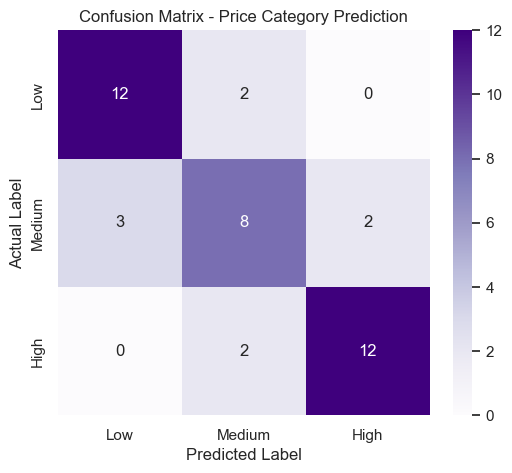

              precision    recall  f1-score   support

        High       0.86      0.86      0.86        14
         Low       0.80      0.86      0.83        14
      Medium       0.67      0.62      0.64        13

    accuracy                           0.78        41
   macro avg       0.77      0.78      0.77        41
weighted avg       0.78      0.78      0.78        41



In [15]:
# Displaying the Classification Confusion Matrix: Compute the raw confusion matrix values
cm = confusion_matrix(y_test_c, y_pred_c, labels=['Low', 'Medium', 'High'])

# Presen matrix using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix - Price Category Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

# Display full precision and recall breakdown
print(classification_report(y_test_c, y_pred_c))

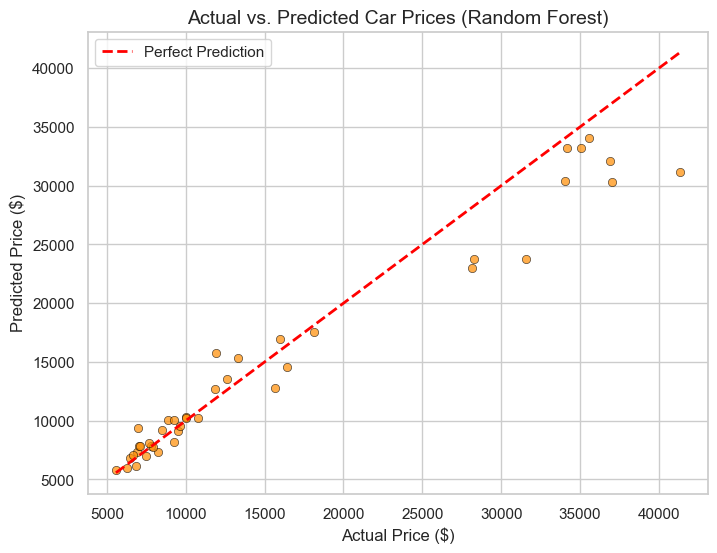

In [16]:
# Visualizing Actual vs. Predicted Prices (Scatter Plot) : Ensure we map the predictions from the 80/20 Random Forest model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test20, y=pred_rf80, alpha=0.7, color='darkorange', edgecolor='black')

# Add a reference line for perfect predictions (where Actual equals Predicted)
perfect_line = np.linspace(min(y_test20), max(y_test20), 100)
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Car Prices (Random Forest)', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend()
plt.savefig('actual_vs_predicted_prices.png', bbox_inches='tight')
plt.show()